In [66]:
import pandas as pd
import numpy as np
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [67]:
reviews_df = pd.read_csv('data/movie_reviews.csv', index_col = 0)
reviews_df.head()

,review_id,movie_name,year,reviewer_name,review_text,rated,year_api,genre,directors,writers,actors,plot,first_genre,first_actor,first_director,first_writer,first_actor_gender,first_director_gender,first_writer_gender
0,1,Lethal Weapon 3,1992.0,J. Boyajian,"About 20 minutes into LETHAL WEAPON 3, my neph...",R,1992,"Action, Crime, Thriller",Richard Donner,"Jeffrey Boam, Robert Mark Kamen, Shane Black","Mel Gibson, Danny Glover, Joe Pesci",Martin Riggs and Roger Murtaugh pursue a forme...,Action,Mel Gibson,Richard Donner,Jeffrey Boam,female,male,male
1,2,Lethal Weapon 3,1999.0,Frank Maloney,LETHAL WEAPON 3 is a film directed by Richard ...,R,1992,"Action, Crime, Thriller",Richard Donner,"Jeffrey Boam, Robert Mark Kamen, Shane Black","Mel Gibson, Danny Glover, Joe Pesci",Martin Riggs and Roger Murtaugh pursue a forme...,Action,Mel Gibson,Richard Donner,Jeffrey Boam,female,male,male
2,3,Lethal Weapon 3,1995.0,Brian L.,"120 min., R, Comedy/Action, 1992\nDirector: Ri...",R,1992,"Action, Crime, Thriller",Richard Donner,"Jeffrey Boam, Robert Mark Kamen, Shane Black","Mel Gibson, Danny Glover, Joe Pesci",Martin Riggs and Roger Murtaugh pursue a forme...,Action,Mel Gibson,Richard Donner,Jeffrey Boam,female,male,male
3,4,Lethal Weapon 3,1979.0,Mark Santora,It has been a couple of years since we last sa...,R,1992,"Action, Crime, Thriller",Richard Donner,"Jeffrey Boam, Robert Mark Kamen, Shane Black","Mel Gibson, Danny Glover, Joe Pesci",Martin Riggs and Roger Murtaugh pursue a forme...,Action,Mel Gibson,Richard Donner,Jeffrey Boam,female,male,male
4,5,Lethal Weapon 3,1997.0,Jose R.,I went to this movie with very low expectation...,R,1992,"Action, Crime, Thriller",Richard Donner,"Jeffrey Boam, Robert Mark Kamen, Shane Black","Mel Gibson, Danny Glover, Joe Pesci",Martin Riggs and Roger Murtaugh pursue a forme...,Action,Mel Gibson,Richard Donner,Jeffrey Boam,female,male,male


In [68]:
reviews_df.shape

(18862, 19)

In [69]:
reviews_df.describe().T

,count,mean,std,min,25%,50%,75%,max
review_id,18862.0,9431.500000,5445.134724,1.0,4716.25,9431.5,14146.75,18862.0
year,18491.0,1993.897734,11.033940,1913.0,1994.00,1997.0,1999.00,2001.0
year_api,18862.0,1996.499046,11.015385,1907.0,1996.00,1998.0,2000.00,2023.0


Year API and year appear to have different data. See if there is one that is more reliable or if they are years for different purposes i.e. year of review vs year of movie release.

In [70]:
reviews_df.describe(include='object').T

,count,unique,top,freq
movie_name,18862,2962,Star Wars: Episode I - The Phantom Menace,80
reviewer_name,18862,1218,Steve Rhodes,1144
review_text,18862,18746,The review above was posted to the\nrec.arts.m...,19
rated,17201,19,R,8953
genre,18855,405,"Comedy, Drama, Romance",1086
directors,18532,1885,Steven Spielberg,191
writers,17909,2588,Woody Allen,134
actors,18647,2910,"Ewan McGregor, Liam Neeson, Natalie Portman",80
plot,18214,2852,Two Jedi escape a hostile blockade to find all...,80
first_genre,18855,23,Comedy,5263


In [71]:
reviews_df.groupby(['movie_name'])[['year', 'year_api']].agg(["mean", "count"]).reset_index().sort_values(by =   (  'year_api', 'count'), ascending = False)

movie_name         year       year_api  \
                                                        mean count     mean   
2464  Star Wars: Episode I - The Phantom Menace  1991.684211    76   1999.0   
2640                                    Titanic  1992.263158    76   1997.0   
1076                                   Godzilla  1993.577465    71   2014.0   
320                    Blair Witch Project, The  1992.485714    70   2020.0   
2270                        Saving Private Ryan  1994.485294    68   1998.0   
...                                         ...          ...   ...      ...   
1521                     Lewis & Clark & George  2000.000000     1   1997.0   
1516                             Let's Get Lost  2000.000000     1   1988.0   
1515                                Let It Ride  1996.000000     1   1989.0   
1514                            Let Him Have It  2000.000000     1   1991.0   
1481                                   Lansdown  1996.000000     1   2001.0   

            
     count  
2464    80  
2640    76  
1076    72  
320     71  
2270    69  
...    ...  
1521     1  
1516     1  
1515     1  
1514     1  
1481     1  

[2962 rows x 5 columns]

year_api seems to be reliable as it has the same mean across movies and the top movies appear to be accurate to release year.... will rename accordingly

In [72]:
reviews_df = reviews_df.rename({'year_api': 'movie_release_year'}, axis =1)
reviews_df.head()

,review_id,movie_name,year,reviewer_name,review_text,rated,movie_release_year,genre,directors,writers,actors,plot,first_genre,first_actor,first_director,first_writer,first_actor_gender,first_director_gender,first_writer_gender
0,1,Lethal Weapon 3,1992.0,J. Boyajian,"About 20 minutes into LETHAL WEAPON 3, my neph...",R,1992,"Action, Crime, Thriller",Richard Donner,"Jeffrey Boam, Robert Mark Kamen, Shane Black","Mel Gibson, Danny Glover, Joe Pesci",Martin Riggs and Roger Murtaugh pursue a forme...,Action,Mel Gibson,Richard Donner,Jeffrey Boam,female,male,male
1,2,Lethal Weapon 3,1999.0,Frank Maloney,LETHAL WEAPON 3 is a film directed by Richard ...,R,1992,"Action, Crime, Thriller",Richard Donner,"Jeffrey Boam, Robert Mark Kamen, Shane Black","Mel Gibson, Danny Glover, Joe Pesci",Martin Riggs and Roger Murtaugh pursue a forme...,Action,Mel Gibson,Richard Donner,Jeffrey Boam,female,male,male
2,3,Lethal Weapon 3,1995.0,Brian L.,"120 min., R, Comedy/Action, 1992\nDirector: Ri...",R,1992,"Action, Crime, Thriller",Richard Donner,"Jeffrey Boam, Robert Mark Kamen, Shane Black","Mel Gibson, Danny Glover, Joe Pesci",Martin Riggs and Roger Murtaugh pursue a forme...,Action,Mel Gibson,Richard Donner,Jeffrey Boam,female,male,male
3,4,Lethal Weapon 3,1979.0,Mark Santora,It has been a couple of years since we last sa...,R,1992,"Action, Crime, Thriller",Richard Donner,"Jeffrey Boam, Robert Mark Kamen, Shane Black","Mel Gibson, Danny Glover, Joe Pesci",Martin Riggs and Roger Murtaugh pursue a forme...,Action,Mel Gibson,Richard Donner,Jeffrey Boam,female,male,male
4,5,Lethal Weapon 3,1997.0,Jose R.,I went to this movie with very low expectation...,R,1992,"Action, Crime, Thriller",Richard Donner,"Jeffrey Boam, Robert Mark Kamen, Shane Black","Mel Gibson, Danny Glover, Joe Pesci",Martin Riggs and Roger Murtaugh pursue a forme...,Action,Mel Gibson,Richard Donner,Jeffrey Boam,female,male,male


Year could possibly be "Review_year" but it appears to have some inaccuracies as there are years before release year

In [73]:
print( 'Movies with year column before movie release year make up ' + \
          str(round((reviews_df['year'] >= reviews_df['movie_release_year']).mean(), 4) * 100)[:4] + "% of total reviews")

Movies with year column before movie release year make up 46.3% of total reviews


This column doesn't appear to be reliable. Dropping column.

In [74]:
reviews_df = reviews_df.drop(['review_id','year'],axis=1)
reviews_df.head()

,movie_name,reviewer_name,review_text,rated,movie_release_year,genre,directors,writers,actors,plot,first_genre,first_actor,first_director,first_writer,first_actor_gender,first_director_gender,first_writer_gender
0,Lethal Weapon 3,J. Boyajian,"About 20 minutes into LETHAL WEAPON 3, my neph...",R,1992,"Action, Crime, Thriller",Richard Donner,"Jeffrey Boam, Robert Mark Kamen, Shane Black","Mel Gibson, Danny Glover, Joe Pesci",Martin Riggs and Roger Murtaugh pursue a forme...,Action,Mel Gibson,Richard Donner,Jeffrey Boam,female,male,male
1,Lethal Weapon 3,Frank Maloney,LETHAL WEAPON 3 is a film directed by Richard ...,R,1992,"Action, Crime, Thriller",Richard Donner,"Jeffrey Boam, Robert Mark Kamen, Shane Black","Mel Gibson, Danny Glover, Joe Pesci",Martin Riggs and Roger Murtaugh pursue a forme...,Action,Mel Gibson,Richard Donner,Jeffrey Boam,female,male,male
2,Lethal Weapon 3,Brian L.,"120 min., R, Comedy/Action, 1992\nDirector: Ri...",R,1992,"Action, Crime, Thriller",Richard Donner,"Jeffrey Boam, Robert Mark Kamen, Shane Black","Mel Gibson, Danny Glover, Joe Pesci",Martin Riggs and Roger Murtaugh pursue a forme...,Action,Mel Gibson,Richard Donner,Jeffrey Boam,female,male,male
3,Lethal Weapon 3,Mark Santora,It has been a couple of years since we last sa...,R,1992,"Action, Crime, Thriller",Richard Donner,"Jeffrey Boam, Robert Mark Kamen, Shane Black","Mel Gibson, Danny Glover, Joe Pesci",Martin Riggs and Roger Murtaugh pursue a forme...,Action,Mel Gibson,Richard Donner,Jeffrey Boam,female,male,male
4,Lethal Weapon 3,Jose R.,I went to this movie with very low expectation...,R,1992,"Action, Crime, Thriller",Richard Donner,"Jeffrey Boam, Robert Mark Kamen, Shane Black","Mel Gibson, Danny Glover, Joe Pesci",Martin Riggs and Roger Murtaugh pursue a forme...,Action,Mel Gibson,Richard Donner,Jeffrey Boam,female,male,male


### Lets see how dispersed our movie reviews are over time using the movie release year

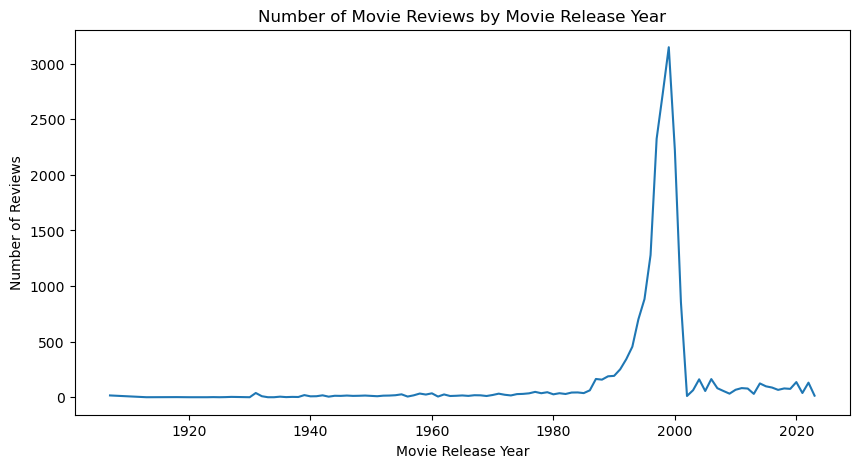

In [75]:

reviews_df.groupby("movie_release_year").size().sort_index().plot(
    kind="line",
    figsize=(10, 5),
    title="Number of Movie Reviews by Movie Release Year"
)

plt.xlabel("Movie Release Year")
plt.ylabel("Number of Reviews")
plt.show()

In [76]:
reviews_df.groupby("movie_release_year").size().sort_values(ascending = False).head(15)

movie_release_year
1999    3147
1998    2728
1997    2324
2000    2223
1996    1279
1995     883
2001     854
1994     702
1993     455
1992     343
1991     252
1990     193
1989     189
1987     165
2006     164
dtype: int64

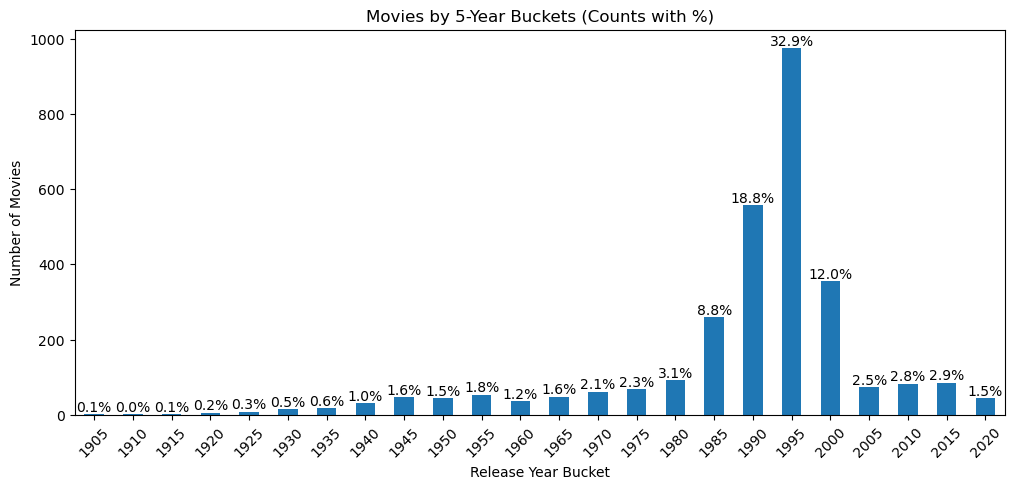

In [77]:
# Compute counts (one movie per row)
s = (
    reviews_df
    .drop_duplicates("movie_name")
    .assign(year_bucket=lambda x: (x["movie_release_year"] // 5) * 5)
    .groupby("year_bucket")
    .size()
    .sort_index()
)

# Plot counts
ax = s.plot(kind="bar", figsize=(12, 5), title="Movies by 5-Year Buckets (Counts with %)")

# Annotate with percentages
total = s.sum()
for i, v in enumerate(s.values):
    pct = v / total * 100
    ax.text(i, v, f"{pct:.1f}%", ha="center", va="bottom")

ax.set_xlabel("Release Year Bucket")
ax.set_ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.show()

70% of reviews are for movies between 1985-2000.

### Let's look at Gender in the movie reviews.

In [78]:
reviews_df['first_director_gender'].value_counts()

first_director_gender
male       16040
female      1544
unknown     1278
Name: count, dtype: int64

Heavily imbalanced dataset. Majority male directors.

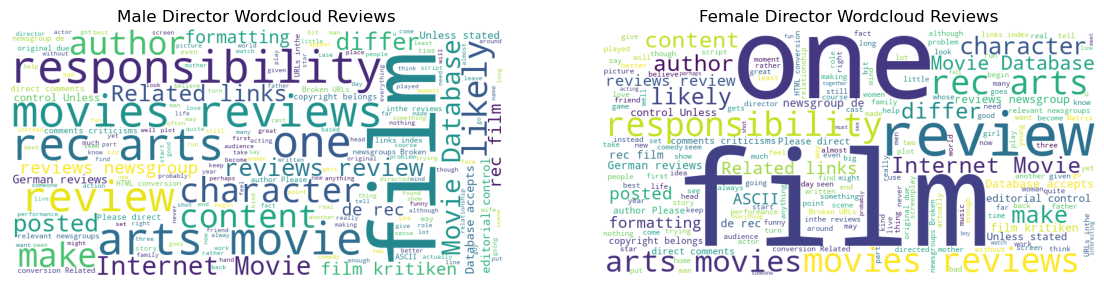

In [79]:
# Word cloud of Descriptions
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text_male = " ".join(reviews_df[reviews_df['first_director_gender'] == 'male']['review_text'])
text_female = " ".join(reviews_df[reviews_df['first_director_gender'] == 'female']['review_text'])


wc_class1 = WordCloud(width=800, height=400, background_color="white").generate(text_male)
wc_class2 = WordCloud(width=800, height=400, background_color="white").generate(text_female)

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.imshow(wc_class1)
plt.axis("off")
plt.title("Male Director Wordcloud Reviews")

plt.subplot(1,2,2)
plt.imshow(wc_class2)
plt.axis("off")
plt.title("Female Director Wordcloud Reviews")

plt.show()

No obvious immediate differences between the 2 director genders movie review text

### Let's look at the movie review text and see possible cleaning that's needed

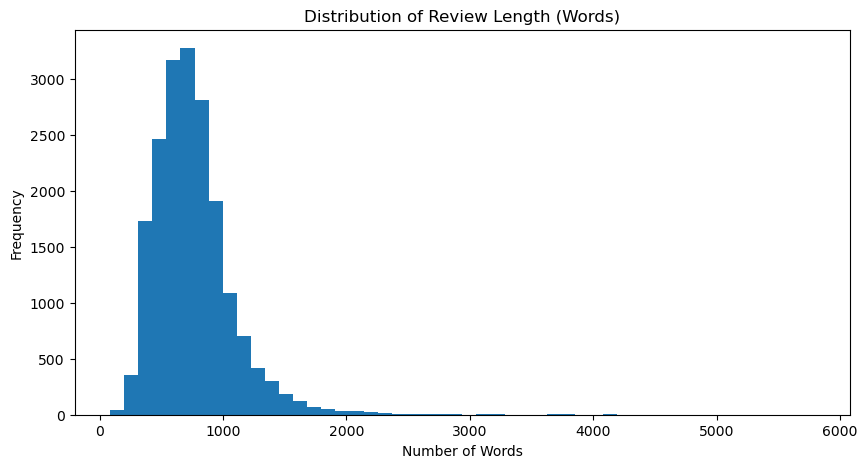

In [80]:
(
    reviews_df["review_text"]
    .str.split()
    .str.len()
    .plot(kind="hist", bins=50, figsize=(10,5), title="Distribution of Review Length (Words)")
)

plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

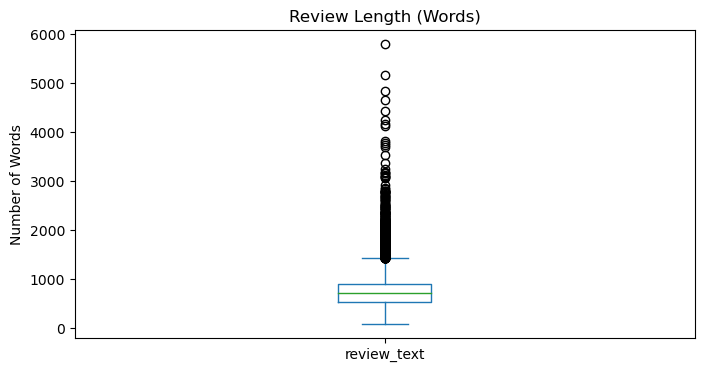

In [81]:
reviews_df["review_text"].str.split().str.len().plot(
    kind="box", figsize=(8,4), title="Review Length (Words)"
)

plt.ylabel("Number of Words")
plt.show()

Most reviews are between 400-1000 words. Some outliers that may need to get truncated or handled.

In [82]:
reviews_df['review_text'].iloc[0]

'About 20 minutes into LETHAL WEAPON 3, my nephew turned to me and\nasked, "Does this movie have a plot?"  And that question represents\neverything that is wrong with LW3.  Quite frankly, the movie is a mess\non a number of levels.  A *funny* mess, to be sure, but still a mess.\nAs the Bard of Avon would put it, it was full of sound and fury,\nsignifying nothing.  It was just about everything a bad sequel usually\nis. o Joe Pesci\'s appearance in the film smacked of dollarsigns.  Not\n      just because he\'s "hot" at the moment, but because it seemed to\n      exploit his contribution to LW2.  His character and performance\n      in LW2 was what made the film -- his presence as "the Third\n      Stooge" made it distinctive enough from the original.  To put\n      him in the third film seemed to be nothing but repetition of a\n      successful ingredient in place of doing something else more\n      innovative.  Storywise, there was absolutely no reason for him\n      to be in the film.

In [106]:
reviews_df['review_text'].iloc[10]

'Starring Jason Biggs, Thomas DeLonge, Mark Hoppus, Travis Barker, Chris\nKlein, Eugene Levy, Thomas Ian Nichols, Natasha Lyonne. Rated R. Hollywood has been buzzing about American Pie for months, with early\nrumors comparing it with There\'s Something About Mary and claiming that\nit "pushes the envelope" with regard to outrageousness. They were wrong.\nIt doesn\'t push the envelope: it throws the envelope at you, and damned\nif it doesn\'t work.\nThis is unquestionably a teen film but the plot is enough to make\nparents wince: a group of high school seniors make a pact that each of\nthem will lose their virginity by graduation time in order to avoid\npotential embarassment in college. There\'s barely a few weeks left and\nfor most of them it looks like prom night is their last hope. Each of\nthem tries to devise their own plan to reach their goal, and some of\nthose plans have unexpected consequences. Of course there has to be some experimentation before they get to the\nreal thing, 

Will need to remove things like newline characters as well as punctuation from movie reviews text. WIll have this as part of the process when cleaning.

### Lets take a look at the most common Genres

In [83]:
reviews_df["genre"].value_counts().head(20)

genre
Comedy, Drama, Romance          1086
Drama                            872
Comedy, Drama                    847
Drama, Romance                   750
Comedy                           607
Comedy, Romance                  595
Action, Adventure, Sci-Fi        490
Documentary                      471
Crime, Drama, Mystery            456
Crime, Drama, Thriller           409
Action, Crime, Drama             382
Action, Adventure, Comedy        376
Action, Crime, Thriller          277
Comedy, Crime                    257
Action, Adventure, Thriller      257
Documentary, Short               246
Animation, Adventure, Comedy     231
Crime, Drama                     228
Action, Comedy, Crime            209
Biography, Drama, History        200
Name: count, dtype: int64

In [84]:
genre_counts = (
    reviews_df
    .drop_duplicates("movie_name")  # avoid counting multiple reviews per movie
    .assign(genre=lambda x: x["genre"].str.split(", "))
    .explode("genre")
    ["genre"]
    .value_counts()
)

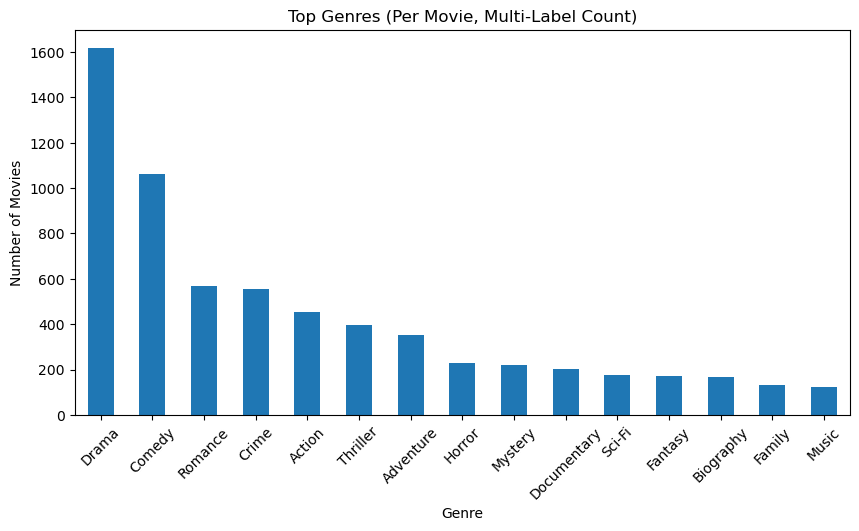

In [85]:
genre_counts.head(15).plot(
    kind="bar",
    figsize=(10,5),
    title="Top Genres (Per Movie, Multi-Label Count)"
)

plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.show()

In [86]:
from itertools import combinations

genre_df = (
    reviews_df
    .drop_duplicates("movie_name")
    .dropna(subset=["genre"])
    .assign(genre=lambda x: x["genre"].str.split(", "))
)

genre_pairs = (
    genre_df["genre"]
    .apply(lambda genres: list(combinations(sorted(set(genres)), 2)))
    .explode()
    .value_counts()
)

genre_pairs.head(15)

genre
(Comedy, Drama)        417
(Drama, Romance)       394
(Crime, Drama)         345
(Comedy, Romance)      294
(Drama, Thriller)      180
(Action, Adventure)    161
(Comedy, Crime)        161
(Biography, Drama)     140
(Action, Drama)        131
(Adventure, Comedy)    130
(Action, Crime)        127
(Crime, Thriller)      127
(Drama, Mystery)       117
(Adventure, Drama)     103
(Action, Thriller)     102
Name: count, dtype: int64

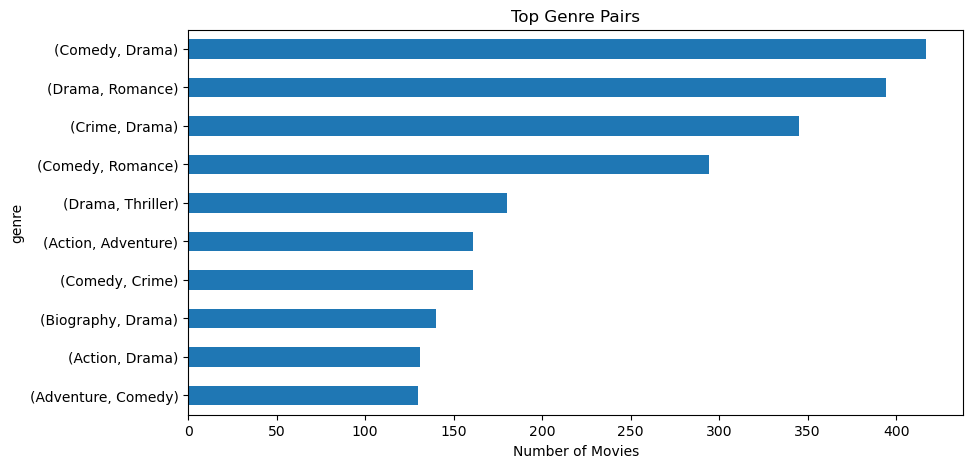

In [87]:
genre_pairs.head(10).plot(
    kind="barh",
    figsize=(10,5),
    title="Top Genre Pairs"
)

plt.gca().invert_yaxis()
plt.xlabel("Number of Movies")
plt.show()

In [88]:
genre_triples = (
    genre_df["genre"]
    .apply(lambda genres: list(combinations(sorted(set(genres)), 3)))
    .explode()
    .value_counts()
)

genre_triples.head(15)

genre
(Comedy, Drama, Romance)         144
(Crime, Drama, Thriller)          68
(Action, Crime, Drama)            52
(Crime, Drama, Mystery)           52
(Crime, Drama, Film-Noir)         35
(Comedy, Crime, Drama)            35
(Action, Adventure, Comedy)       35
(Action, Comedy, Crime)           30
(Action, Adventure, Thriller)     28
(Action, Adventure, Sci-Fi)       25
(Action, Crime, Thriller)         24
(Biography, Drama, History)       24
(Drama, Mystery, Thriller)        22
(Biography, Crime, Drama)         22
(Comedy, Drama, Music)            22
Name: count, dtype: int64

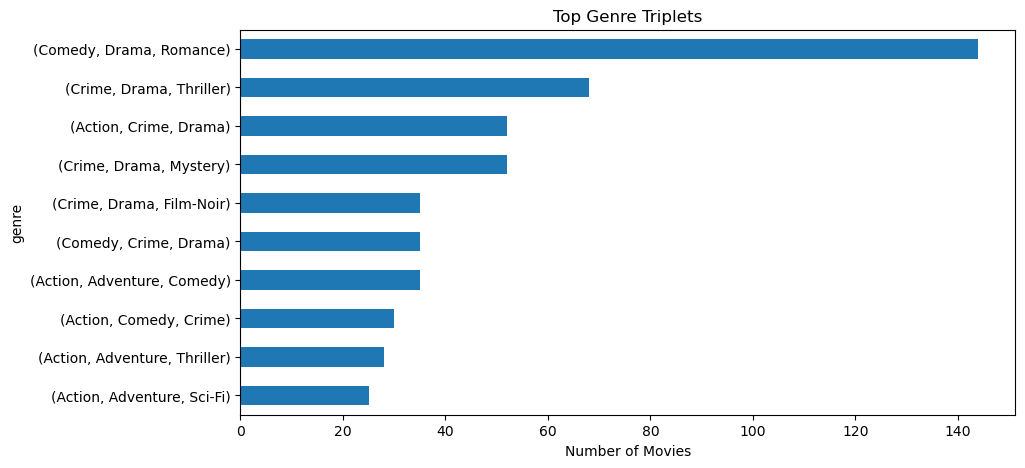

In [89]:
genre_triples.head(10).plot(
    kind="barh",
    figsize=(10,5),
    title="Top Genre Triplets"
)

plt.gca().invert_yaxis()
plt.xlabel("Number of Movies")
plt.show()

In [90]:
reviews_df["review_word_count"] = reviews_df["review_text"].astype(str).apply(lambda x: len(x.split()))
reviews_df

,movie_name,reviewer_name,review_text,rated,movie_release_year,genre,directors,writers,actors,plot,first_genre,first_actor,first_director,first_writer,first_actor_gender,first_director_gender,first_writer_gender,review_word_count
0,Lethal Weapon 3,J. Boyajian,"About 20 minutes into LETHAL WEAPON 3, my neph...",R,1992,"Action, Crime, Thriller",Richard Donner,"Jeffrey Boam, Robert Mark Kamen, Shane Black","Mel Gibson, Danny Glover, Joe Pesci",Martin Riggs and Roger Murtaugh pursue a forme...,Action,Mel Gibson,Richard Donner,Jeffrey Boam,female,male,male,634
1,Lethal Weapon 3,Frank Maloney,LETHAL WEAPON 3 is a film directed by Richard ...,R,1992,"Action, Crime, Thriller",Richard Donner,"Jeffrey Boam, Robert Mark Kamen, Shane Black","Mel Gibson, Danny Glover, Joe Pesci",Martin Riggs and Roger Murtaugh pursue a forme...,Action,Mel Gibson,Richard Donner,Jeffrey Boam,female,male,male,1105
2,Lethal Weapon 3,Brian L.,"120 min., R, Comedy/Action, 1992\nDirector: Ri...",R,1992,"Action, Crime, Thriller",Richard Donner,"Jeffrey Boam, Robert Mark Kamen, Shane Black","Mel Gibson, Danny Glover, Joe Pesci",Martin Riggs and Roger Murtaugh pursue a forme...,Action,Mel Gibson,Richard Donner,Jeffrey Boam,female,male,male,518
3,Lethal Weapon 3,Mark Santora,It has been a couple of years since we last sa...,R,1992,"Action, Crime, Thriller",Richard Donner,"Jeffrey Boam, Robert Mark Kamen, Shane Black","Mel Gibson, Danny Glover, Joe Pesci",Martin Riggs and Roger Murtaugh pursue a forme...,Action,Mel Gibson,Richard Donner,Jeffrey Boam,female,male,male,651
4,Lethal Weapon 3,Jose R.,I went to this movie with very low expectation...,R,1992,"Action, Crime, Thriller",Richard Donner,"Jeffrey Boam, Robert Mark Kamen, Shane Black","Mel Gibson, Danny Glover, Joe Pesci",Martin Riggs and Roger Murtaugh pursue a forme...,Action,Mel Gibson,Richard Donner,Jeffrey Boam,female,male,male,614
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18857,Camilla,James Berardinelli,U.S. Availability: varies (early 1995) \nRunn...,PG-13,1994,Drama,Deepa Mehta,"Ali Jennings, Paul Quarrington","Jessica Tandy, Bridget Fonda, Hume Cronyn",Vincent and Freda Lopez are a young married To...,Drama,Jessica Tandy,Deepa Mehta,Ali Jennings,female,female,male,575
18858,Watch the K Foundation Burn a Million Quid,Nicholas Parrott,Watch the K Foundation Burn a Million Quid\nTh...,NaN,1995,Documentary,Gimpo,NaN,"Jimi Cauty, Bill Drummond",Former members of the techno music group The K...,Documentary,Jimi Cauty,Gimpo,NaN,male,unknown,unknown,560
18859,Let It Ride,Shane Burridge,Comedy set during one day at the racetrack may...,PG-13,1989,"Comedy, Action",Joe Pytka,"Jay Cronley, Nancy Dowd","Richard Dreyfuss, Teri Garr, David Johansen",A nosy cab driver gets a hot tip on a race hor...,Comedy,Richard Dreyfuss,Joe Pytka,Jay Cronley,male,male,male,599
18860,Treasure Island,Max Messier,filmcritic.com presents a review from staff me...,PG,1950,"Adventure, Family",Byron Haskin,"Lawrence Edward Watkin, Robert Louis Stevenson","Bobby Driscoll, Robert Newton, Basil Sydney",The treasure seeking adventures of young Jim H...,Adventure,Bobby Driscoll,Byron Haskin,Lawrence Edward Watkin,male,male,male,658


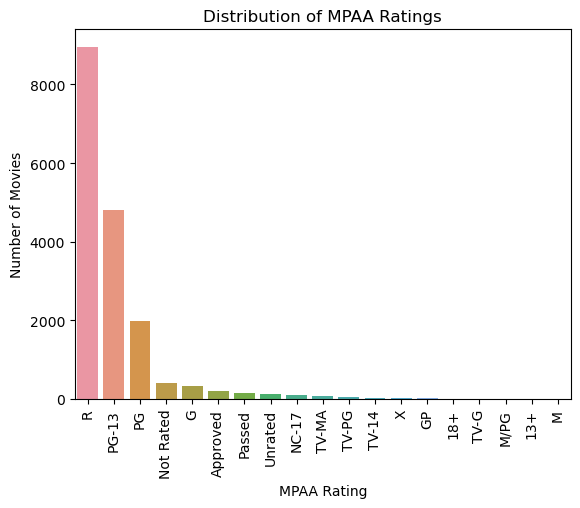

In [91]:
sns.countplot(data = reviews_df, x = "rated", order = reviews_df["rated"].value_counts().index)
plt.title("Distribution of MPAA Ratings")
plt.xlabel("MPAA Rating")
plt.ylabel("Number of Movies")
plt.xticks(rotation = 90)
plt.show()

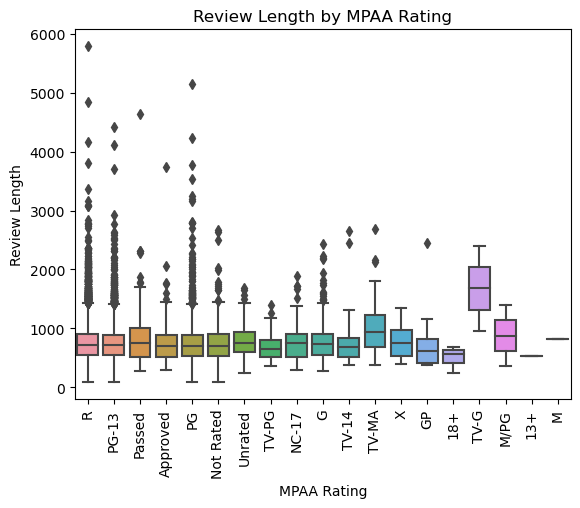

In [92]:
sns.boxplot(data = reviews_df, x = "rated", y = "review_word_count")
plt.title("Review Length by MPAA Rating")
plt.xlabel("MPAA Rating")
plt.ylabel("Review Length")
plt.xticks(rotation = 90)
plt.show()

#### May be worth considering dropping unrated movies? Also there seems to be some movies that are on the TV rating system

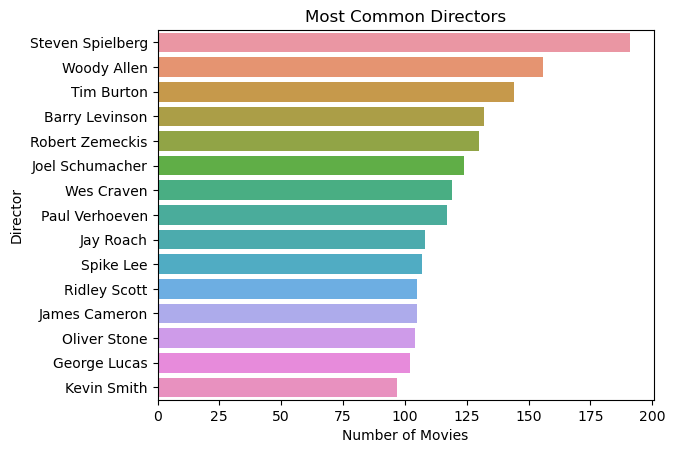

In [93]:
top_directors = reviews_df["first_director"].value_counts().head(15)
sns.barplot(x = top_directors.values, y = top_directors.index)
plt.title("Most Common Directors")
plt.xlabel("Number of Movies")
plt.ylabel("Director")
plt.show()

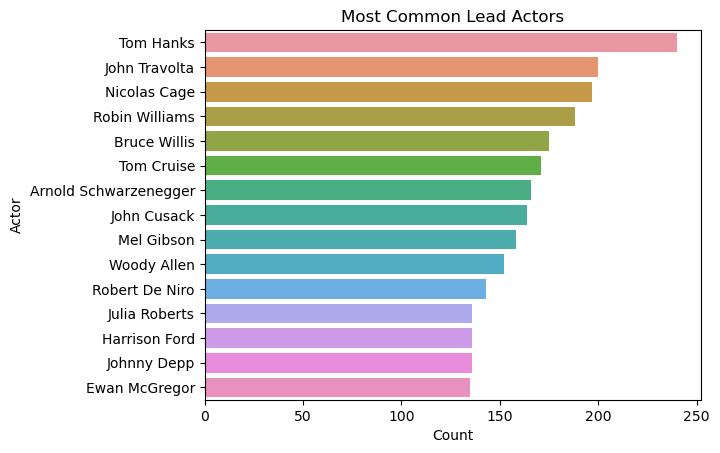

In [94]:
top_actors = reviews_df["first_actor"].value_counts().head(15)
sns.barplot(x = top_actors.values, y = top_actors.index)
plt.title("Most Common Lead Actors")
plt.xlabel("Count")
plt.ylabel("Actor")
plt.show()

#### Both director and actor almost entirely filled by men

## Taking a look at just the movies represented in the dataset, not the reviews

In [95]:
#this dataset is so we can look at the movie data for each movie and not have it double counted
movie_df = reviews_df.drop_duplicates(subset=["movie_name", "movie_release_year"])
movie_df

,movie_name,reviewer_name,review_text,rated,movie_release_year,genre,directors,writers,actors,plot,first_genre,first_actor,first_director,first_writer,first_actor_gender,first_director_gender,first_writer_gender,review_word_count
0,Lethal Weapon 3,J. Boyajian,"About 20 minutes into LETHAL WEAPON 3, my neph...",R,1992,"Action, Crime, Thriller",Richard Donner,"Jeffrey Boam, Robert Mark Kamen, Shane Black","Mel Gibson, Danny Glover, Joe Pesci",Martin Riggs and Roger Murtaugh pursue a forme...,Action,Mel Gibson,Richard Donner,Jeffrey Boam,female,male,male,634
5,American Pie,Michael Dequina,If you see the trailer for _American_Pie_ in t...,R,1999,Comedy,"Paul Weitz, Chris Weitz",Adam Herz,"Jason Biggs, Chris Klein, Thomas Ian Nicholas",Four teenage boys enter a pact to lose their v...,Comedy,Jason Biggs,Paul Weitz,Adam Herz,male,male,male,540
42,Outbreak,Mark R.,The film starts with a quote saying that virus...,R,1995,"Action, Drama, Thriller",Wolfgang Petersen,"Laurence Dworet, Robert Roy Pool","Dustin Hoffman, Rene Russo, Morgan Freeman",Army doctors struggle to find a cure for a dea...,Action,Dustin Hoffman,Wolfgang Petersen,Laurence Dworet,male,male,female,1702
49,Starship Troopers,William Wallace,Here is the problem with it. While it is gener...,R,1997,"Action, Adventure, Sci-Fi",Paul Verhoeven,"Edward Neumeier, Robert A. Heinlein","Casper Van Dien, Denise Richards, Dina Meyer","Humans in a fascist, militaristic future wage ...",Action,Casper Van Dien,Paul Verhoeven,Edward Neumeier,male,male,male,891
110,Primal Fear,Steve Kong,Primal Fear is a movie in which Richard Gere g...,R,1996,"Crime, Drama, Mystery",Gregory Hoblit,"William Diehl, Steve Shagan, Ann Biderman","Richard Gere, Laura Linney, Edward Norton","An altar boy is accused of murdering a priest,...",Crime,Richard Gere,Gregory Hoblit,William Diehl,male,male,male,320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18857,Camilla,James Berardinelli,U.S. Availability: varies (early 1995) \nRunn...,PG-13,1994,Drama,Deepa Mehta,"Ali Jennings, Paul Quarrington","Jessica Tandy, Bridget Fonda, Hume Cronyn",Vincent and Freda Lopez are a young married To...,Drama,Jessica Tandy,Deepa Mehta,Ali Jennings,female,female,male,575
18858,Watch the K Foundation Burn a Million Quid,Nicholas Parrott,Watch the K Foundation Burn a Million Quid\nTh...,NaN,1995,Documentary,Gimpo,NaN,"Jimi Cauty, Bill Drummond",Former members of the techno music group The K...,Documentary,Jimi Cauty,Gimpo,NaN,male,unknown,unknown,560
18859,Let It Ride,Shane Burridge,Comedy set during one day at the racetrack may...,PG-13,1989,"Comedy, Action",Joe Pytka,"Jay Cronley, Nancy Dowd","Richard Dreyfuss, Teri Garr, David Johansen",A nosy cab driver gets a hot tip on a race hor...,Comedy,Richard Dreyfuss,Joe Pytka,Jay Cronley,male,male,male,599
18860,Treasure Island,Max Messier,filmcritic.com presents a review from staff me...,PG,1950,"Adventure, Family",Byron Haskin,"Lawrence Edward Watkin, Robert Louis Stevenson","Bobby Driscoll, Robert Newton, Basil Sydney",The treasure seeking adventures of young Jim H...,Adventure,Bobby Driscoll,Byron Haskin,Lawrence Edward Watkin,male,male,male,658


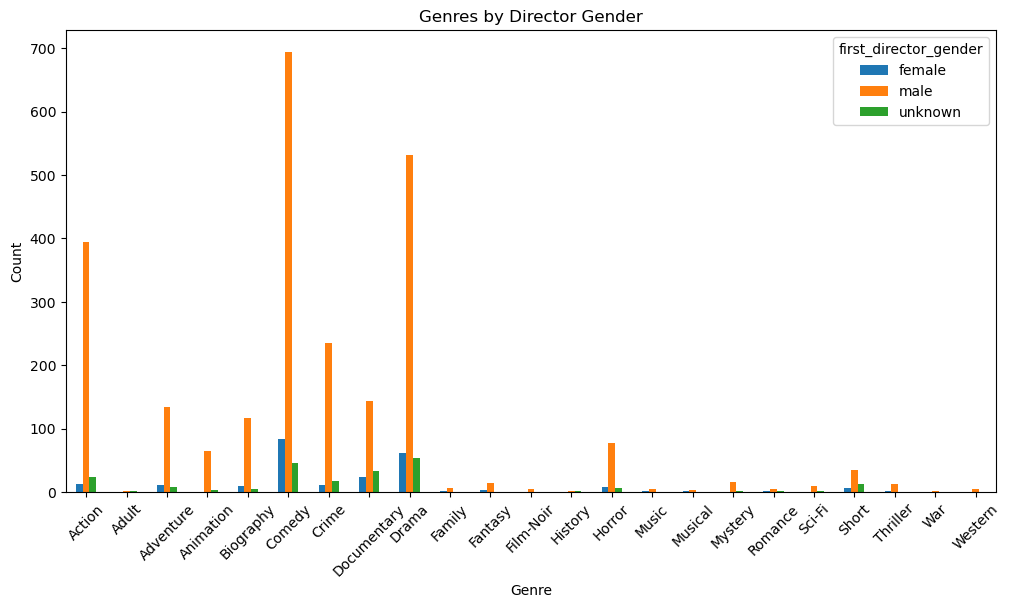

In [96]:
genre_gender = pd.crosstab(
    movie_df["first_genre"],
    movie_df["first_director_gender"])
genre_gender.plot(
    kind="bar",
    figsize=(12,6))
plt.title("Genres by Director Gender")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

#### Men are just much more represented as directors in the films represented in this dataset

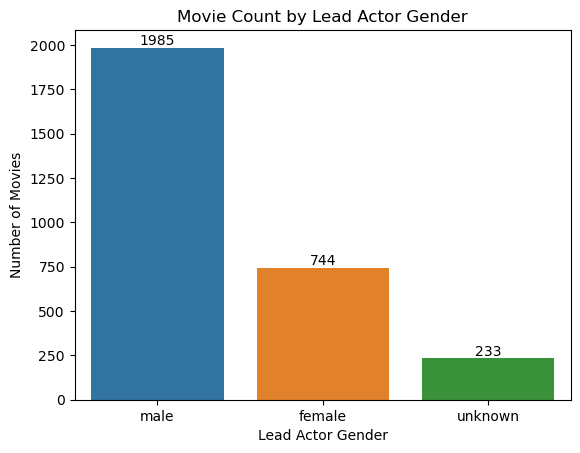

In [97]:
gender_counts = (movie_df["first_actor_gender"].fillna("unknown").value_counts())
ax = sns.barplot(x = gender_counts.index, y = gender_counts.values)

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom")
plt.title("Movie Count by Lead Actor Gender")
plt.xlabel("Lead Actor Gender")
plt.ylabel("Number of Movies")
plt.show()

#### Much more movies led by men in the dataset than women

In [98]:
#below shows the most common combinations in the dataset of genre and rating for movies
combo_counts = (movie_df.groupby(["first_genre", "rated"]).size().reset_index(name = "count").sort_values("count", ascending = False))
combo_counts.head(15)

,first_genre,rated,count
51,Comedy,R,339
87,Drama,R,251
9,Action,R,212
49,Comedy,PG-13,207
65,Crime,R,172
48,Comedy,PG,140
7,Action,PG-13,113
85,Drama,PG-13,107
108,Horror,R,64
38,Biography,R,64


## Back to Reviews

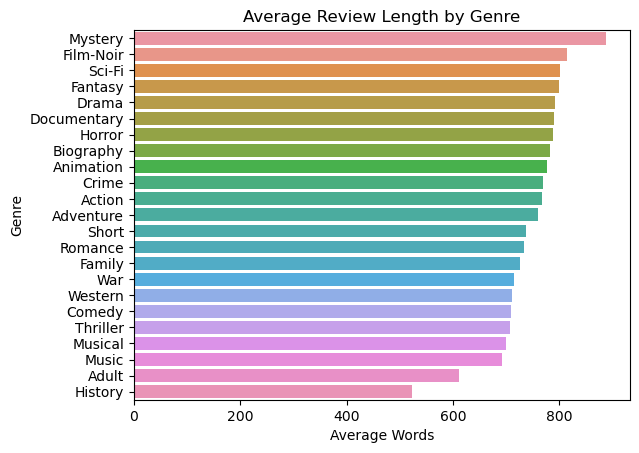

In [99]:
genre_review_length = (reviews_df.groupby("first_genre")["review_word_count"].mean().sort_values(ascending = False))
sns.barplot(x = genre_review_length.values, y = genre_review_length.index)
plt.title("Average Review Length by Genre")
plt.xlabel("Average Words")
plt.ylabel("Genre")
plt.show()

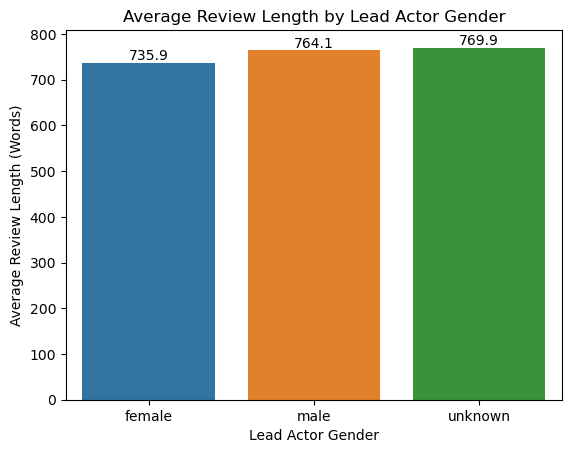

In [100]:
# Average review length by lead actor gender
review_length_gender = (reviews_df.groupby("first_actor_gender")["review_word_count"].mean().reset_index())
ax = sns.barplot(data=review_length_gender, x = "first_actor_gender", y = "review_word_count")
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom")
plt.title("Average Review Length by Lead Actor Gender")
plt.xlabel("Lead Actor Gender")
plt.ylabel("Average Review Length (Words)")

plt.show()

#### We see that for men-led movies, reviews tend to be slightly longer, but not by much

In [119]:
import re

pattern = r"The review above was posted to the.*?Related links: index of all rec\.arts\.movies\.reviews reviews"

# Count reviews containing the boilerplate
count = reviews_df["review_text"].astype(str).str.contains(
    pattern,
    regex=True,
    flags=re.DOTALL
).sum()

print("Number of reviews containing boilerplate text:", count)

Number of reviews containing boilerplate text: 18861


In [120]:
import re

pattern = r"The review above was posted to the.*?Related links: index of all rec\.arts\.movies\.reviews reviews"

reviews_df["clean_review_text"] = (
    reviews_df["review_text"]
    .astype(str)
    .str.replace(
        pattern,
        "",
        regex=True,
        flags=re.DOTALL
    )
)

In [121]:
#boilerplate is removed
reviews_df['clean_review_text'].iloc[0]

'About 20 minutes into LETHAL WEAPON 3, my nephew turned to me and\nasked, "Does this movie have a plot?"  And that question represents\neverything that is wrong with LW3.  Quite frankly, the movie is a mess\non a number of levels.  A *funny* mess, to be sure, but still a mess.\nAs the Bard of Avon would put it, it was full of sound and fury,\nsignifying nothing.  It was just about everything a bad sequel usually\nis. o Joe Pesci\'s appearance in the film smacked of dollarsigns.  Not\n      just because he\'s "hot" at the moment, but because it seemed to\n      exploit his contribution to LW2.  His character and performance\n      in LW2 was what made the film -- his presence as "the Third\n      Stooge" made it distinctive enough from the original.  To put\n      him in the third film seemed to be nothing but repetition of a\n      successful ingredient in place of doing something else more\n      innovative.  Storywise, there was absolutely no reason for him\n      to be in the film.

#### Now we can effectively look at wordclouds

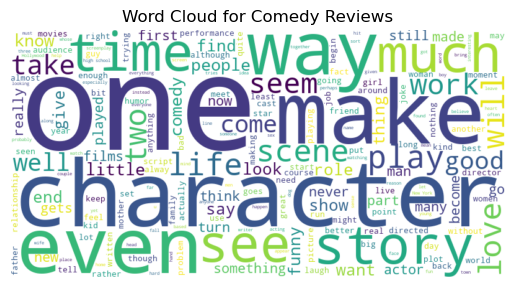

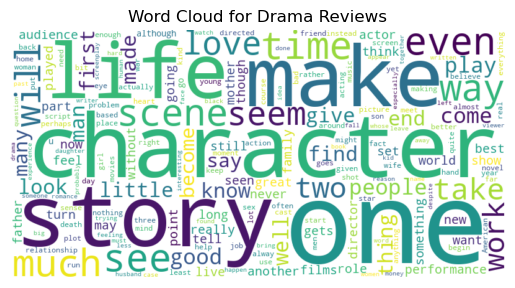

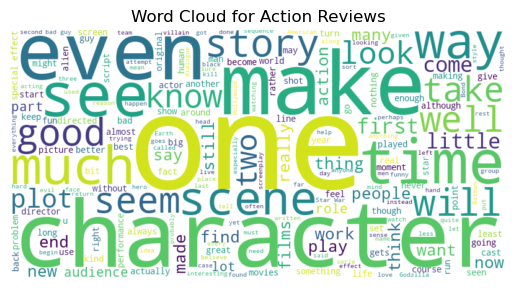

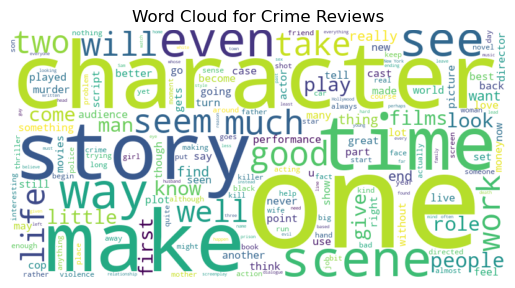

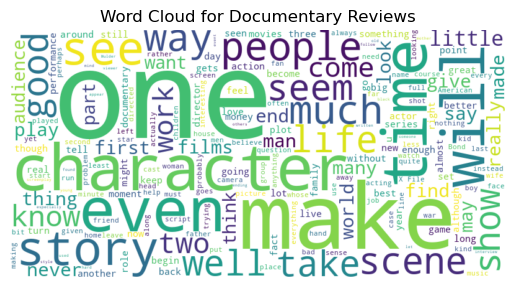

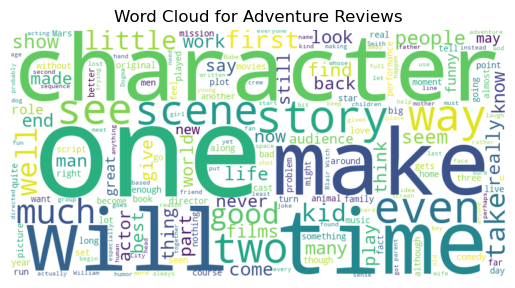

In [125]:
from wordcloud import WordCloud, STOPWORDS
custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    "of",
    "and",
    "the",
    "in",
    "from",
    "for",
    "is",
    "a",
    "review",
    "this",
    "that",
    "film",
    "movie"])
top_genres = movie_df["first_genre"].value_counts().head(6).index
for genre in top_genres:
    text = " ".join(
        reviews_df[reviews_df["first_genre"] == genre]["clean_review_text"]
        .dropna()
        .astype(str))
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white",
        stopwords=custom_stopwords).generate(text)
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud for {genre} Reviews")
    plt.show()

In [127]:
from sklearn.feature_extraction.text import TfidfVectorizer

custom_stopwords.update([
    "one", "time", "good", "bad", "movie", "film",
    "story", "character", "characters", "films",
    "director", "make", "made", "much", "even",
    "well", "see", "will", "way", "first", "two",
    "life", "man", "woman", "people", "little",
    "many", "new", "know", "world"
])
# Combine all reviews within each genre
genre_text = (
    reviews_df.groupby("first_genre")["clean_review_text"]
    .apply(lambda texts: " ".join(texts.dropna().astype(str)))
)

vectorizer = TfidfVectorizer(
    stop_words=list(custom_stopwords),
    max_features=5000,
    min_df=2
)

tfidf_matrix = vectorizer.fit_transform(genre_text)

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=genre_text.index,
    columns=vectorizer.get_feature_names_out()
)

# Show top distinctive words for each genre
for genre in tfidf_df.index:
    top_words = tfidf_df.loc[genre].sort_values(ascending=False).head(15)
    print(f"\nTop TF-IDF words for {genre}:")
    print(top_words)

/Users/kirkwaller/anaconda3/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['aren', 'couldn', 'didn', 'doesn', 'don', 'hadn', 'hasn', 'haven', 'isn', 'let', 'll', 'mustn', 're', 'shan', 'shouldn', 've', 'wasn', 'weren', 'won', 'wouldn'] not in stop_words.
  warnings.warn(



Top TF-IDF words for Action:
action     0.195688
plot       0.112778
really     0.099895
movies     0.097844
scenes     0.094584
effects    0.094526
don        0.091624
star       0.091604
re         0.089602
best       0.087185
back       0.084417
never      0.083386
scene      0.082110
big        0.080595
doesn      0.079116
Name: Action, dtype: float64

Top TF-IDF words for Adult:
sharon         0.361149
religion       0.239353
faith          0.136858
work           0.127316
god            0.120320
tony           0.119677
weekend        0.114422
us             0.106097
robert         0.104833
questions      0.104833
issues         0.100432
laura          0.098495
dinner         0.093970
armageddon     0.089757
involvement    0.089757
Name: Adult, dtype: float64

Top TF-IDF words for Adventure:
best       0.095678
don        0.095328
back       0.089545
really     0.085883
rock       0.082311
never      0.082035
mission    0.079936
great      0.079761
cast       0.079697
smith      

#### Some of the above don't look great because they are clearly trained on very few movies, but some of the genres with higher counts do look like the kind of represent the genre

## The below is kind of random, but wanted to see if a higher ratio of movies with female actors/director has the word 'annoying' in them to try to detect and sexism. The opposite sems to be the case, but we could try other words

In [129]:
# Create lowercase cleaned text
reviews_df_copy = reviews_df.copy()

reviews_df_copy["review_lower"] = (
    reviews_df_copy["clean_review_text"]
    .astype(str)
    .str.lower())

# Check if review contains annoying/anoying
reviews_df_copy["contains_annoying"] = reviews_df_copy["review_lower"].str.contains(
    r"\bannoying\b|\banoying\b",
    regex=True)

# Calculate proportions by lead actor gender
annoying_stats = (
    reviews_df_copy.groupby("first_actor_gender")
    .agg(
        total_reviews=("contains_annoying", "count"),
        annoying_reviews=("contains_annoying", "sum")))

annoying_stats["annoying_ratio"] = (
    annoying_stats["annoying_reviews"] /
    annoying_stats["total_reviews"])

annoying_stats

,total_reviews,annoying_reviews,annoying_ratio
first_actor_gender,,,
female,4370,208,0.047597
male,13282,670,0.050444
unknown,1210,61,0.050413


In [130]:
annoying_director_stats = (
    reviews_df_copy.groupby("first_director_gender")
    .agg(
        total_reviews=("contains_annoying", "count"),
        annoying_reviews=("contains_annoying", "sum")))

annoying_director_stats["annoying_ratio"] = (
    annoying_director_stats["annoying_reviews"] /
    annoying_director_stats["total_reviews"])

annoying_director_stats

,total_reviews,annoying_reviews,annoying_ratio
first_director_gender,,,
female,1544,73,0.047280
male,16040,815,0.050810
unknown,1278,51,0.039906
